# 🌌 Vortical Gravity Simulation
This notebook demonstrates the **G-Recovery Mechanism** in the Vortical Gravity framework. 
We visualize how the un-damping of the lattice solves the Dark Matter anomaly without non-baryonic particles.

**Core Constant:** $G_{max} \approx 5.46 G_0$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class VorticalEngine:
    def __init__(self):
        self.G0 = 6.67430e-11
        self.G_max = 5.46320 * self.G0
        self.eta = 1e82
        self.rho_p = 1e96
        self.gamma = 0.85
        self.S_earth = 4.46320

    def get_v_curve(self, mass, max_r):
        r_kpc = np.linspace(1, max_r, 100)
        vn, vv, gr = [], [], []
        for r in r_kpc:
            r_m = r * 3.086e19
            v_n = np.sqrt((self.G0 * mass) / r_m) / 1000
            
            # Lattice Stress & G-Recovery
            rho = mass / ((4/3) * np.pi * r_m**3)
            X = self.eta * (rho / self.rho_p)
            g_ratio = (1 + self.S_earth) / (1 + (X**self.gamma))
            
            vn.append(v_n)
            gr.append(g_ratio)
            vv.append(v_n * np.sqrt(g_ratio))
        return r_kpc, vn, vv, gr

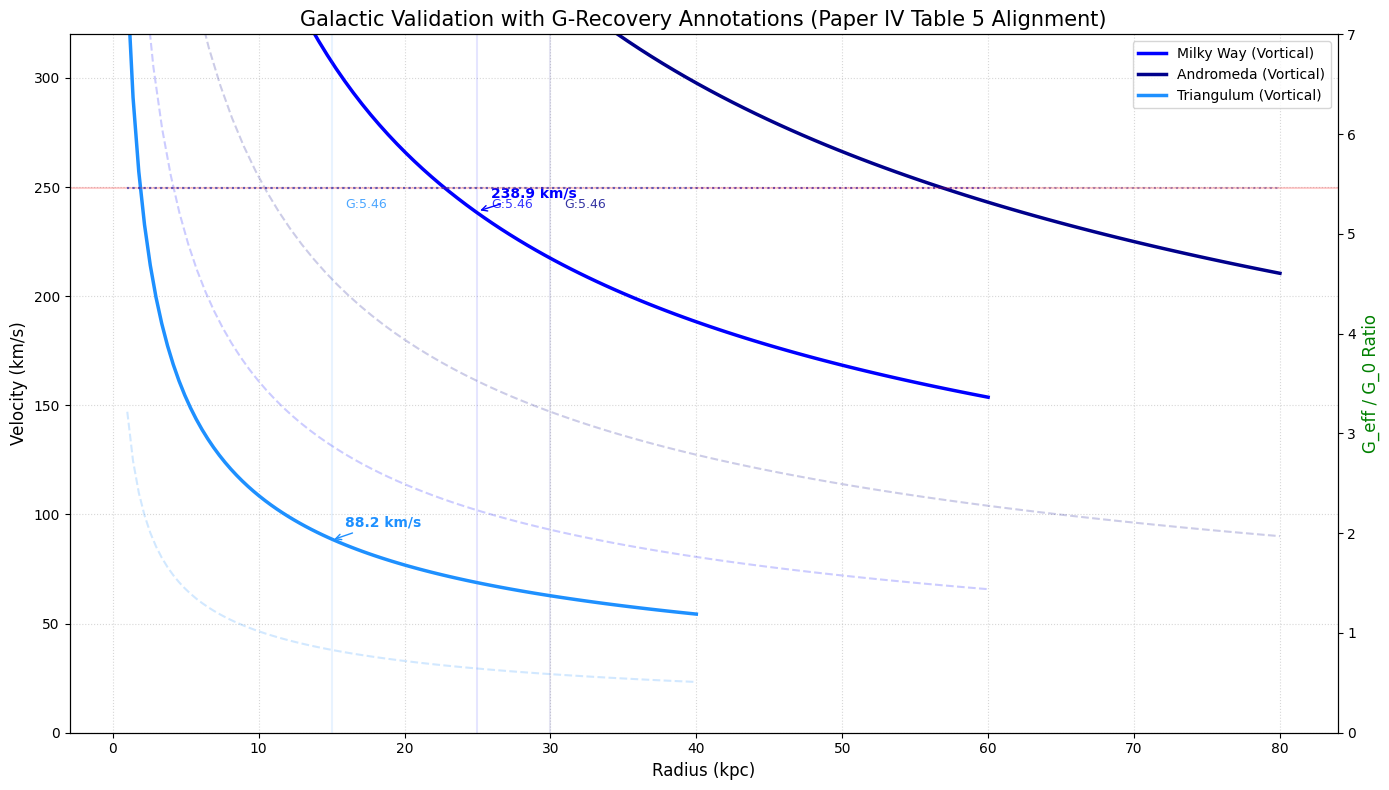

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class VorticalEngine:
    def __init__(self):
        self.G0 = 6.67430e-11
        self.eta = 1e82
        self.rho_p = 1e96
        self.gamma = 0.85
        self.S_earth = 4.46320
        self.G_max = self.G0 * (1 + self.S_earth)

    def simulate_galaxy(self, mass, max_r):
        r_kpc = np.linspace(1, max_r, 100)
        v_newton, v_vortical, g_ratios = [], [], []
        for r in r_kpc:
            r_m = r * 3.086e19
            vn = np.sqrt((self.G0 * mass) / r_m) / 1000
            rho = mass / ((4/3) * np.pi * r_m**3)
            X = self.eta * (rho / self.rho_p)
            g_ratio = (1 + self.S_earth) / (1 + (X**self.gamma))
            v_vortical.append(vn * np.sqrt(g_ratio))
            v_newton.append(vn)
            g_ratios.append(g_ratio)
        return r_kpc, v_newton, v_vortical, g_ratios

# Engine initialization
engine = VorticalEngine()

# Graph settings
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Specific verification point data to add annotations
validation_points = {
    "Milky Way": {"M": 1.20e41, "R_focus": 25, "max_r": 60, "color": "blue"},
    "Andromeda": {"M": 3.00e41, "R_focus": 30, "max_r": 80, "color": "darkblue"},
    "Triangulum": {"M": 1.00e40, "R_focus": 15, "max_r": 40, "color": "dodgerblue"}
}

for name, data in validation_points.items():
    r, vn, vv, gr = engine.simulate_galaxy(data["M"], data["max_r"])
    
    # 1. Main graph output
    ax1.plot(r, vv, label=f'{name} (Vortical)', color=data['color'], linewidth=2.5)
    ax1.plot(r, vn, linestyle='--', color=data['color'], alpha=0.2)
    ax2.plot(r, gr, linestyle=':', color=data['color'], alpha=0.4)

    # 2. Extracting numerical values ​​at a specific radius (R_focus) and adding comments
    idx = (np.abs(r - data["R_focus"])).argmin() # Find nearest index
    v_val = vv[idx]
    g_val = gr[idx]
    
    # Display vertical dashed lines on the graph
    ax1.axvline(x=data["R_focus"], color=data['color'], linestyle='-', alpha=0.1)
    
    # Velocity Annotation
    ax1.annotate(f'{v_val:.1f} km/s', 
                 xy=(data["R_focus"], v_val), 
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=10, fontweight='bold', color=data['color'],
                 arrowprops=dict(arrowstyle='->', color=data['color']))

    # G-Ratio Annotation
    ax2.annotate(f'G:{g_val:.2f}', 
                 xy=(data["R_focus"], g_val), 
                 xytext=(10, -15), textcoords='offset points',
                 fontsize=9, color=data['color'], alpha=0.8)

# Layout cleanup
ax1.set_xlabel('Radius (kpc)', fontsize=12)
ax1.set_ylabel('Velocity (km/s)', fontsize=12)
ax1.set_ylim(0, 320)
ax2.set_ylabel('G_eff / G_0 Ratio', color='green', fontsize=12)
ax2.set_ylim(0, 7)
ax2.axhline(y=5.46, color='red', linestyle='-', alpha=0.2)

plt.title('Galactic Validation with G-Recovery Annotations (Paper IV Table 5 Alignment)', fontsize=15)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
